# 🚢 Titanic Survival Prediction

**Task:** Predict survival of passengers using demographic and ticket information.

**Dataset:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)

This notebook walks through the full workflow:

1. Load the data
2. Exploratory data analysis (EDA)
3. Feature engineering
4. Preprocessing pipeline
5. Model comparison with cross-validation
6. Train & evaluate the best model
7. Generate predictions / submission file
8. Make custom predictions

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams["figure.figsize"] = (7, 4)
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


## 1. Load the data

In [2]:
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Missing values

In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0].to_frame("missing")
missing["% of rows"] = (missing["missing"] / len(train) * 100).round(1)
missing

,missing,% of rows
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


## 3. Exploratory Data Analysis

Overall survival rate: 38.4%


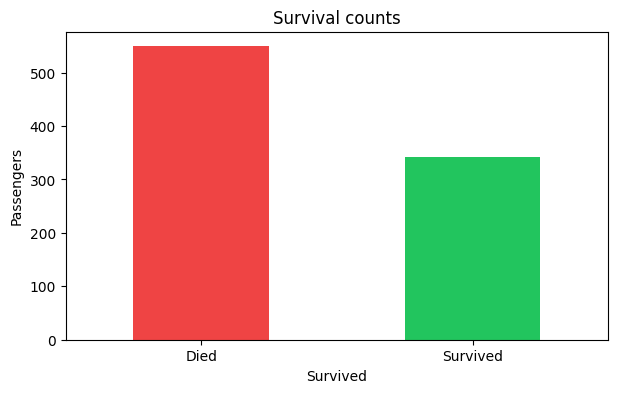

In [6]:
rate = train["Survived"].mean()
print(f"Overall survival rate: {rate*100:.1f}%")
train["Survived"].value_counts().rename({0: "Died", 1: "Survived"}).plot(
    kind="bar", color=["#ef4444", "#22c55e"])
plt.title("Survival counts"); plt.ylabel("Passengers"); plt.xticks(rotation=0); plt.show()

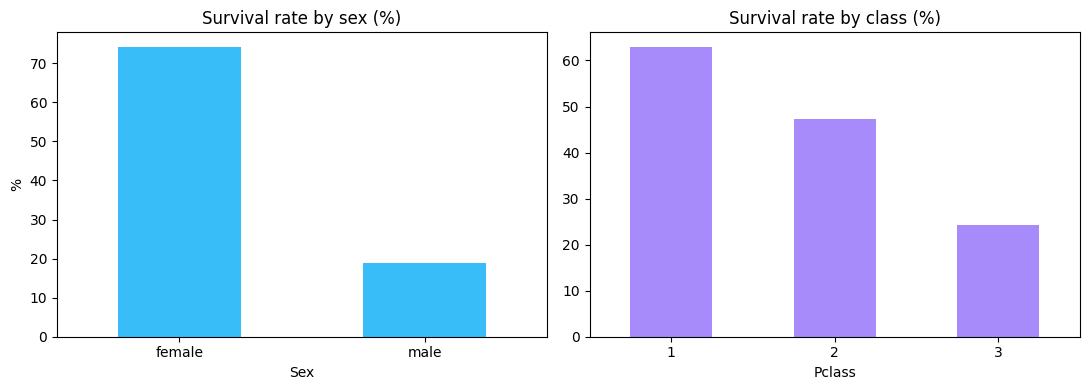

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
(train.groupby("Sex")["Survived"].mean() * 100).plot(kind="bar", ax=axes[0], color="#38bdf8")
axes[0].set_title("Survival rate by sex (%)"); axes[0].set_ylabel("%"); axes[0].tick_params(axis="x", rotation=0)
(train.groupby("Pclass")["Survived"].mean() * 100).plot(kind="bar", ax=axes[1], color="#a78bfa")
axes[1].set_title("Survival rate by class (%)"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

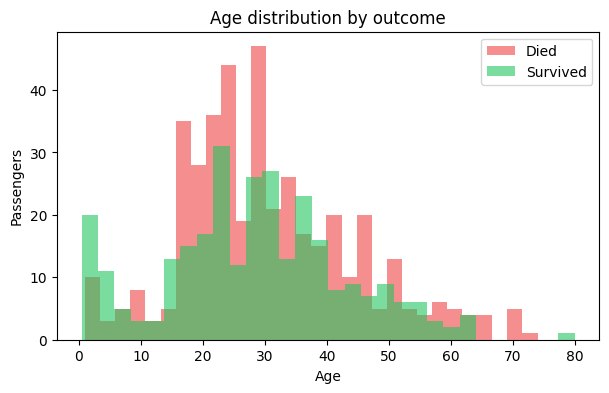

In [8]:
fig, ax = plt.subplots()
ax.hist(train[train.Survived == 0]["Age"].dropna(), bins=30, alpha=0.6, label="Died", color="#ef4444")
ax.hist(train[train.Survived == 1]["Age"].dropna(), bins=30, alpha=0.6, label="Survived", color="#22c55e")
ax.set_title("Age distribution by outcome"); ax.set_xlabel("Age"); ax.set_ylabel("Passengers"); ax.legend(); plt.show()

## 4. Feature Engineering

In [9]:
def engineer_features(df):
    df = df.copy()
    df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
    rare = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
    df["Title"] = df["Title"].replace(rare, "Rare")
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["Deck"] = df["Cabin"].str[0].fillna("Unknown")
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    return df

train = engineer_features(train)
test = engineer_features(test)
train[["Name", "Title", "FamilySize", "IsAlone", "Deck", "HasCabin"]].head()

,Name,Title,FamilySize,IsAlone,Deck,HasCabin
0,"Braund, Mr. Owen Harris",Mr,2,0,Unknown,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,C,1
2,"Heikkinen, Miss. Laina",Miss,1,1,Unknown,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,C,1
4,"Allen, Mr. William Henry",Mr,1,1,Unknown,0


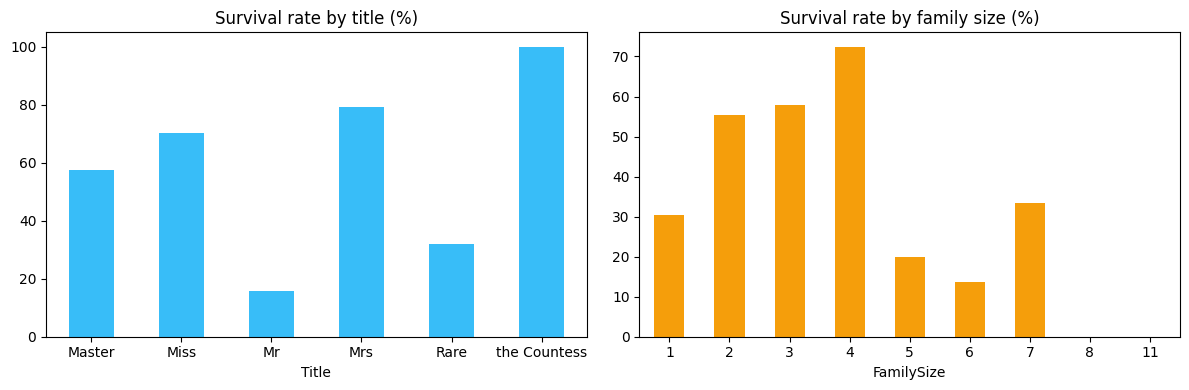

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(train.groupby("Title")["Survived"].mean() * 100).plot(kind="bar", ax=axes[0], color="#38bdf8")
axes[0].set_title("Survival rate by title (%)"); axes[0].tick_params(axis="x", rotation=0)
(train.groupby("FamilySize")["Survived"].mean() * 100).plot(kind="bar", ax=axes[1], color="#f59e0b")
axes[1].set_title("Survival rate by family size (%)"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 5. Preprocessing & model pipeline

In [11]:
NUMERIC_FEATURES = ["Age", "Fare", "FamilySize", "SibSp", "Parch", "IsAlone", "HasCabin"]
CATEGORICAL_FEATURES = ["Pclass", "Sex", "Embarked", "Title", "Deck"]

def build_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("num", numeric, NUMERIC_FEATURES),
                              ("cat", categorical, CATEGORICAL_FEATURES)])

X = train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = train["Survived"]
print("Feature matrix:", X.shape)

Feature matrix: (891, 12)


## 6. Model comparison (5-fold cross-validation)

LogisticRegression   0.8305 (+/- 0.0177)


RandomForest         0.8339 (+/- 0.0132)


GradientBoosting     0.8417 (+/- 0.0167)

Best model: GradientBoosting (0.8417)


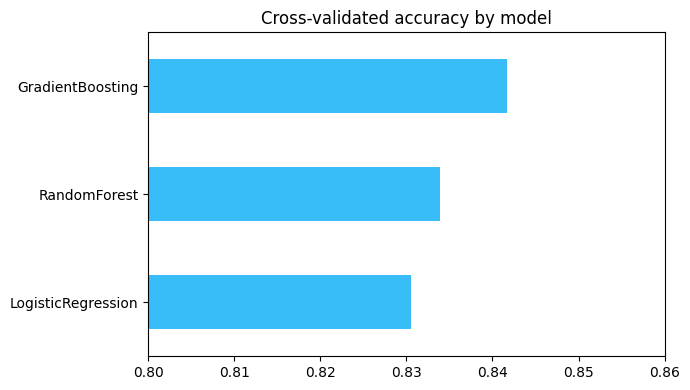

In [12]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=400, max_depth=6,
                                           min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                   max_depth=3, random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = {}
for name, model in models.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("clf", model)])
    s = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    scores[name] = s.mean()
    print(f"{name:<20s} {s.mean():.4f} (+/- {s.std():.4f})")

best_name = max(scores, key=scores.get)
print("\nBest model:", best_name, f"({scores[best_name]:.4f})")
pd.Series(scores).sort_values().plot(kind="barh", color="#38bdf8")
plt.title("Cross-validated accuracy by model"); plt.xlim(0.80, 0.86); plt.tight_layout(); plt.show()

## 7. Train & evaluate the best model

In [13]:
best_pipe = Pipeline([("prep", build_preprocessor()), ("clf", models[best_name])])
best_pipe.fit(X, y)

# Honest out-of-fold predictions for evaluation
oof = cross_val_predict(best_pipe, X, y, cv=cv, n_jobs=-1)
print(f"Out-of-fold accuracy: {accuracy_score(y, oof):.4f}\n")
print(classification_report(y, oof, target_names=["Died", "Survived"]))

Out-of-fold accuracy: 0.8418

              precision    recall  f1-score   support

        Died       0.85      0.91      0.88       549
    Survived       0.83      0.74      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



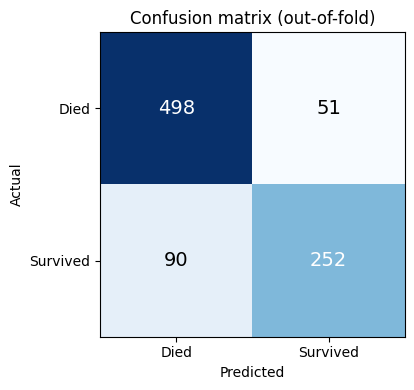

In [14]:
cm = confusion_matrix(y, oof)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Died", "Survived"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Died", "Survived"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion matrix (out-of-fold)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.tight_layout(); plt.show()

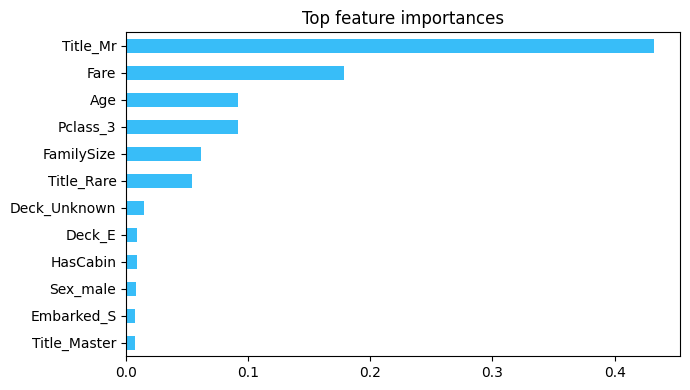

In [15]:
prep = best_pipe.named_steps["prep"]
clf = best_pipe.named_steps["clf"]
names = [n.replace("num__", "").replace("cat__", "") for n in prep.get_feature_names_out()]
imp = clf.feature_importances_ if hasattr(clf, "feature_importances_") else np.abs(clf.coef_).ravel()
pd.Series(imp, index=names).sort_values().tail(12).plot(kind="barh", color="#38bdf8")
plt.title("Top feature importances"); plt.tight_layout(); plt.show()

## 8. Predict on the test set & save the submission

In [16]:
MODEL_DIR = ROOT / "models"; OUTPUT_DIR = ROOT / "outputs"
MODEL_DIR.mkdir(exist_ok=True); OUTPUT_DIR.mkdir(exist_ok=True)

X_test = test[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
test_pred = best_pipe.predict(X_test).astype(int)
submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": test_pred})
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)
joblib.dump(best_pipe, MODEL_DIR / "titanic_model.joblib")
print("Saved model      -> models/titanic_model.joblib")
print("Saved submission -> outputs/submission.csv")
submission.head()

Saved model      -> models/titanic_model.joblib
Saved submission -> outputs/submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## 9. Try a custom prediction

In [17]:
def predict_passenger(pclass, sex, age, fare, sibsp=0, parch=0,
                      embarked="S", title="Mr", deck="Unknown"):
    family = sibsp + parch + 1
    row = pd.DataFrame([{
        "Age": age, "Fare": fare, "FamilySize": family, "SibSp": sibsp, "Parch": parch,
        "IsAlone": 1 if family == 1 else 0, "HasCabin": 0 if deck == "Unknown" else 1,
        "Pclass": pclass, "Sex": sex, "Embarked": embarked, "Title": title, "Deck": deck,
    }], columns=NUMERIC_FEATURES + CATEGORICAL_FEATURES)
    pred = int(best_pipe.predict(row)[0])
    proba = float(best_pipe.predict_proba(row)[0][1])
    print(f"{'SURVIVED' if pred else 'DID NOT SURVIVE'}  (probability = {proba*100:.1f}%)")

print("1st-class female, age 28:"); predict_passenger(1, "female", 28, 80, title="Mrs", deck="C")
print("3rd-class male, age 30:  "); predict_passenger(3, "male", 30, 7.5, title="Mr")

1st-class female, age 28:
SURVIVED  (probability = 96.2%)
3rd-class male, age 30:  
DID NOT SURVIVE  (probability = 5.1%)


## Conclusion

- Engineered features (**Title, FamilySize, IsAlone, Deck, HasCabin**) on top of the raw fields.
- Compared **Logistic Regression**, **Random Forest**, and **Gradient Boosting** with 5-fold cross-validation inside a leakage-free pipeline.
- **Gradient Boosting** performed best at ~**0.84** cross-validated accuracy.
- The fitted pipeline is saved to `models/` and predictions to `outputs/submission.csv`.